# Protein Folding Benchmark Analysis

This notebook loads benchmark score CSVs, checks target/model coverage, plots lDDT-C-alpha and TM-score summaries, and exports reusable figures/tables.

In [1]:
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "scores").exists():
            return path
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
default_targets = PROJECT_ROOT / "data" / "targets" / "targets_first5.csv"
if not default_targets.exists():
    default_targets = PROJECT_ROOT / "data" / "targets" / "targets.csv"
TARGETS_CSV = Path(os.environ.get("TARGETS_CSV", str(default_targets)))
RESULTS_DIR = Path(os.environ.get("RESULTS_DIR", str(PROJECT_ROOT / "data" / "scores")))
if not TARGETS_CSV.is_absolute():
    TARGETS_CSV = PROJECT_ROOT / TARGETS_CSV
if not RESULTS_DIR.is_absolute():
    RESULTS_DIR = PROJECT_ROOT / RESULTS_DIR
SCORES_DIR = RESULTS_DIR
FIGURES_DIR = PROJECT_ROOT / "figures" / "benchmark"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY = "lddt_ca"
SECONDARY = "tmalign_tm_score_ref"
TOPK_MODE = {"boltz2": "top-5", "chai1": "top-5", "colabfold": "top-5", "esmfold": "top-1", "omegafold": "top-1", "openfold": "top-1 current setup"}

targets = pd.read_csv(TARGETS_CSV) if TARGETS_CSV.exists() else pd.DataFrame(columns=["target_id", "pdb_id", "chain_id", "sequence", "notes"])
if "sequence" in targets:
    targets["sequence_length"] = targets["sequence"].fillna("").astype(str).str.len()
else:
    targets["sequence_length"] = np.nan
def derive_size_bin(n):
    if pd.isna(n):
        return "unknown"
    if n < 150:
        return "small"
    if n < 400:
        return "medium"
    return "large"
def size_bin_from_notes(row):
    notes = str(row.get("notes", ""))
    match = re.search(r"size_bin=([^;|]+)", notes)
    return match.group(1).strip() if match else derive_size_bin(row.get("sequence_length"))
targets["size_bin"] = targets.apply(size_bin_from_notes, axis=1) if not targets.empty else []

summary_path = SCORES_DIR / "all_targets_model_summary.csv"
all_summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
score_files = sorted(path for path in SCORES_DIR.rglob("*_scores.csv") if not path.name.startswith("all_targets"))
scores = pd.concat([pd.read_csv(path).assign(score_file=str(path.relative_to(SCORES_DIR))) for path in score_files], ignore_index=True) if score_files else pd.DataFrame()
MODEL_ORDER = sorted(scores["model"].dropna().unique()) if not scores.empty and "model" in scores else []
if "rank" not in scores.columns:
    scores["rank"] = scores["prediction"].astype(str).str.extract(r"rank_(\d+)\.pdb").astype(float) if not scores.empty else []
if "rank" in scores:
    scores["rank"] = pd.to_numeric(scores["rank"], errors="coerce")
print(f"Targets CSV: {TARGETS_CSV}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Discovered score files: {len(score_files)}")
display(targets[[c for c in ["target_id", "pdb_id", "chain_id", "sequence_length", "size_bin", "notes"] if c in targets.columns]].head(20))
scores.head()

Targets CSV: /home/chen0040/localhome/projects/Protein-Folding-Benchmark/data/targets/targets_first5.csv
Results dir: /home/chen0040/localhome/projects/Protein-Folding-Benchmark/data/scores
Discovered score files: 7


/tmp/ipykernel_1655123/2677103442.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scores = pd.concat([pd.read_csv(path).assign(score_file=str(path.relative_to(SCORES_DIR))) for path in score_files], ignore_index=True) if score_files else pd.DataFrame()


,target_id,pdb_id,chain_id,sequence_length,size_bin,notes
0,7ROA_chainA,7ROA,A,115,small,casp_round=CASP15; target_id=T1104; target_len...
1,7QIH_chainA,7QIH,A,111,small,casp_round=CASP15; target_id=T1106s1; target_l...
2,8ORK_chainA,8ORK,A,448,large,casp_round=CASP15; target_id=T1112; target_len...
3,7UYX_chainA,7UYX,A,167,medium,casp_round=CASP15; target_id=T1113; target_len...
4,7UTD_chainA,7UTD,A,512,medium,casp_round=CASP15; target_id=T1114s1; target_l...


,target_id,model,prediction,match_mode,n_ref_ca,n_pred_ca,n_aligned_ca,missing_ref_resseq,missing_pred_resseq,ca_rmsd,...,error,score_file,pdb_id,chain_id,rank,inference_time_sec,inference_time_sec_per_prediction,prediction_count,success,return_code
0,1UAO_chignolin,boltz2,rank_003.pdb,sequential,10,10,10,NaN,NaN,0.614098,...,NaN,1UAO_chignolin_scores.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1UAO_chignolin,boltz2,rank_005.pdb,sequential,10,10,10,NaN,NaN,0.562096,...,NaN,1UAO_chignolin_scores.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1UAO_chignolin,boltz2,rank_001.pdb,sequential,10,10,10,NaN,NaN,0.781959,...,NaN,1UAO_chignolin_scores.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1UAO_chignolin,boltz2,rank_002.pdb,sequential,10,10,10,NaN,NaN,0.682308,...,NaN,1UAO_chignolin_scores.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1UAO_chignolin,boltz2,rank_004.pdb,sequential,10,10,10,NaN,NaN,0.751069,...,NaN,1UAO_chignolin_scores.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Validate Data

Check target/model coverage, prediction counts, missing model-target pairs, and whether each model produced top-5 or top-1 predictions.

In [2]:
if scores.empty:
    print("No score CSVs discovered yet. Run scoring before metric plots.")
    prediction_counts = pd.DataFrame(columns=["target_id", "model", "n_predictions"])
    missing = pd.DataFrame()
    topk = prediction_counts.copy()
else:
    target_count = scores["target_id"].nunique()
    model_count = scores["model"].nunique()
    prediction_counts = scores.groupby(["target_id", "model"]).size().rename("n_predictions").reset_index()
    expected_targets = sorted(targets["target_id"].dropna().unique()) if "target_id" in targets and not targets.empty else sorted(scores["target_id"].unique())
    expected = pd.MultiIndex.from_product([expected_targets, MODEL_ORDER], names=["target_id", "model"]).to_frame(index=False)
    coverage = expected.merge(prediction_counts, on=["target_id", "model"], how="left")
    missing = coverage[coverage["n_predictions"].isna()].copy()
    topk = prediction_counts.copy()
    topk["top_k_mode"] = topk["model"].map(TOPK_MODE).fillna("unknown")
    print(f"Targets with scores: {target_count}")
    print(f"Models with scores: {model_count}")

display(topk.sort_values(["target_id", "model"]))
display(missing)

Targets with scores: 2
Models with scores: 6


,target_id,model,n_predictions,top_k_mode
0,1UAO_chignolin,boltz2,5,top-5
1,1UAO_chignolin,chai1,5,top-5
2,1UAO_chignolin,colabfold,5,top-5
3,1UAO_chignolin,esmfold,1,top-1
4,1UAO_chignolin,omegafold,1,top-1
5,1UAO_chignolin,openfold,1,top-1 current setup
6,1UBQ_ubiquitin,boltz2,5,top-5
7,1UBQ_ubiquitin,chai1,5,top-5
8,1UBQ_ubiquitin,colabfold,5,top-5
9,1UBQ_ubiquitin,esmfold,1,top-1


,target_id,model,n_predictions
0,7QIH_chainA,boltz2,NaN
1,7QIH_chainA,chai1,NaN
2,7QIH_chainA,colabfold,NaN
3,7QIH_chainA,esmfold,NaN
4,7QIH_chainA,omegafold,NaN
5,7QIH_chainA,openfold,NaN
6,7ROA_chainA,boltz2,NaN
7,7ROA_chainA,chai1,NaN
8,7ROA_chainA,colabfold,NaN
9,7ROA_chainA,esmfold,NaN


## Overall Model Ranking

Rank models by mean/median lDDT-C-alpha. TM-score normalized by reference length is shown as secondary information.

,model,mean_lddt_ca,median_lddt_ca,mean_tm_score_ref,n_predictions
4,omegafold,0.933545,0.933545,NaN,2
3,esmfold,0.933322,0.933322,NaN,2
1,chai1,0.920104,0.924459,NaN,10
5,openfold,0.916113,0.916113,NaN,2
0,boltz2,0.858711,0.879732,NaN,10
2,colabfold,0.809809,0.875000,NaN,10


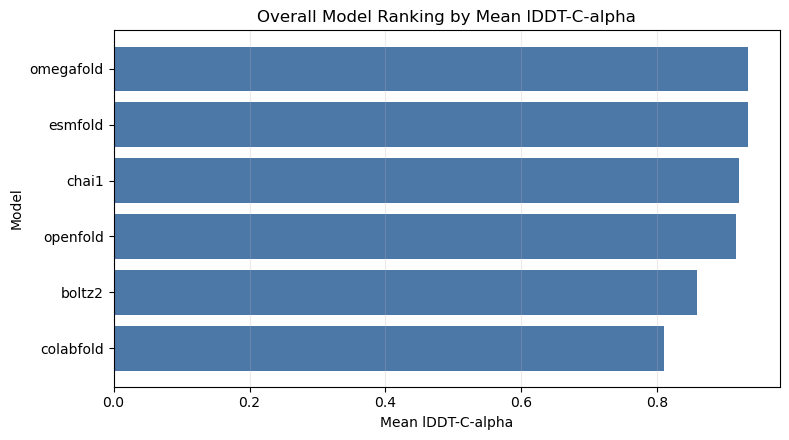

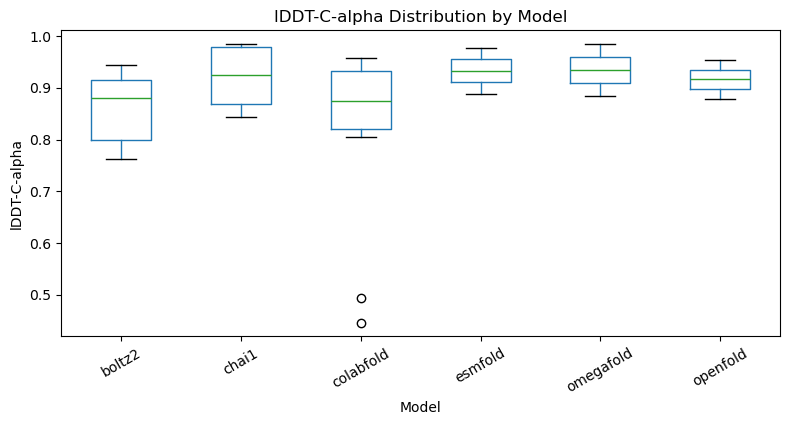

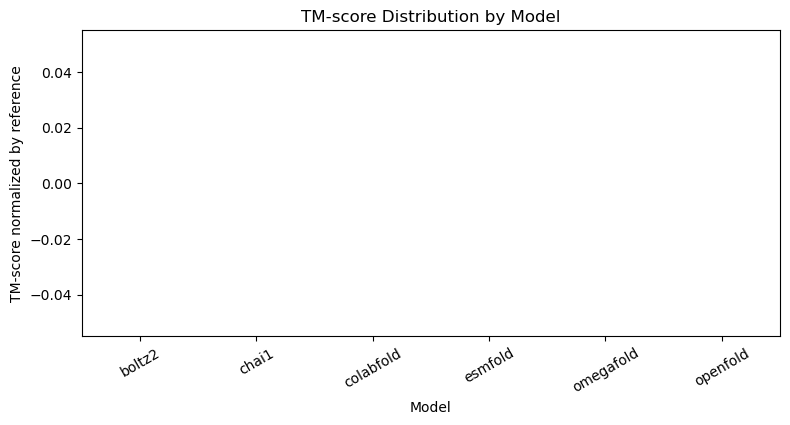

/tmp/ipykernel_1655123/987259205.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best", fontsize="small")


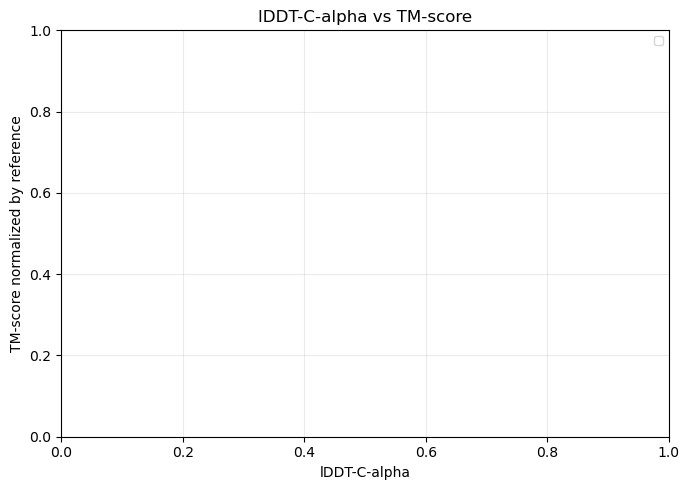

,size_bin,model,mean_lddt_ca,median_lddt_ca,n_predictions


In [3]:
model_stats = scores.groupby("model").agg(
    mean_lddt_ca=(PRIMARY, "mean"),
    median_lddt_ca=(PRIMARY, "median"),
    mean_tm_score_ref=(SECONDARY, "mean"),
    n_predictions=(PRIMARY, "size"),
).reset_index()
model_stats["model"] = pd.Categorical(model_stats["model"], categories=MODEL_ORDER, ordered=True)
model_stats = model_stats.sort_values("mean_lddt_ca", ascending=False)
display(model_stats)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = model_stats.sort_values("mean_lddt_ca", ascending=True)
ax.barh(plot_df["model"].astype(str), plot_df["mean_lddt_ca"], color="#4C78A8")
ax.set_xlabel("Mean lDDT-C-alpha")
ax.set_ylabel("Model")
ax.set_title("Overall Model Ranking by Mean lDDT-C-alpha")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_mean_lddt_ca.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(max(8, 0.8 * max(1, len(MODEL_ORDER))), 4.5))
scores.boxplot(column=PRIMARY, by="model", ax=ax, grid=False, rot=30)
ax.set_title("lDDT-C-alpha Distribution by Model")
ax.set_xlabel("Model")
ax.set_ylabel("lDDT-C-alpha")
fig.suptitle("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_lddt_ca_boxplot.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(max(8, 0.8 * max(1, len(MODEL_ORDER))), 4.5))
scores.boxplot(column=SECONDARY, by="model", ax=ax, grid=False, rot=30)
ax.set_title("TM-score Distribution by Model")
ax.set_xlabel("Model")
ax.set_ylabel("TM-score normalized by reference")
fig.suptitle("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_tm_score_ref_boxplot.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model, group in scores.dropna(subset=[PRIMARY, SECONDARY]).groupby("model"):
    ax.scatter(group[PRIMARY], group[SECONDARY], label=model, alpha=0.75)
ax.set_xlabel("lDDT-C-alpha")
ax.set_ylabel("TM-score normalized by reference")
ax.set_title("lDDT-C-alpha vs TM-score")
ax.legend(loc="best", fontsize="small")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lddt_ca_vs_tm_score_ref.png", dpi=160)
plt.show()

target_scores = scores.merge(targets[["target_id", "size_bin"]], on="target_id", how="left") if "target_id" in targets else scores.assign(size_bin="unknown")
size_summary = target_scores.groupby(["size_bin", "model"]).agg(mean_lddt_ca=(PRIMARY, "mean"), median_lddt_ca=(PRIMARY, "median"), n_predictions=(PRIMARY, "size")).reset_index()
display(size_summary.sort_values(["size_bin", "mean_lddt_ca"], ascending=[True, False]))

## Timing Summary

Inference time columns are merged from `results/run_metadata.csv` when available. Missing timing values are allowed for older score files.

In [4]:
timing_cols = ["inference_time_sec", "inference_time_sec_per_prediction", "prediction_count", "success", "return_code"]
has_timing = all(col in scores.columns for col in ["inference_time_sec", "inference_time_sec_per_prediction"])
if not has_timing:
    print("Timing columns are not present in the loaded score CSVs.")
else:
    scores["inference_time_sec"] = pd.to_numeric(scores["inference_time_sec"], errors="coerce")
    scores["inference_time_sec_per_prediction"] = pd.to_numeric(scores["inference_time_sec_per_prediction"], errors="coerce")
    scores["prediction_count"] = pd.to_numeric(scores.get("prediction_count"), errors="coerce")
    if "success" in scores:
        success_text = scores["success"].astype(str).str.lower()
        scores["timing_success"] = success_text.isin(["true", "1", "yes"])
    else:
        scores["timing_success"] = scores["inference_time_sec"].notna()

    timing_summary = scores.groupby("model").agg(
        n_scored_predictions=(PRIMARY, "size"),
        n_unique_targets=("target_id", "nunique"),
        mean_lddt_ca=(PRIMARY, "mean"),
        median_lddt_ca=(PRIMARY, "median"),
        mean_tm_score=(SECONDARY, "mean"),
        median_tm_score=(SECONDARY, "median"),
        mean_inference_time_sec=("inference_time_sec", "mean"),
        median_inference_time_sec=("inference_time_sec", "median"),
        mean_inference_time_sec_per_prediction=("inference_time_sec_per_prediction", "mean"),
        median_inference_time_sec_per_prediction=("inference_time_sec_per_prediction", "median"),
        success_rate=("timing_success", "mean"),
    ).reset_index().sort_values(["median_lddt_ca", "median_inference_time_sec_per_prediction"], ascending=[False, True])
    display(timing_summary)

    best_metric = scores.copy()
    best_metric["_primary_sort"] = pd.to_numeric(best_metric[PRIMARY], errors="coerce")
    best_metric["_secondary_sort"] = pd.to_numeric(best_metric[SECONDARY], errors="coerce")
    best_by_target = best_metric.sort_values(["_primary_sort", "_secondary_sort"], ascending=[False, False]).groupby(["target_id", "model"], as_index=False).first()
    best_timing_summary = best_by_target.groupby("model").agg(
        n_targets=("target_id", "nunique"),
        median_best_lddt_ca=(PRIMARY, "median"),
        median_best_tm_score=(SECONDARY, "median"),
        median_inference_time_sec=("inference_time_sec", "median"),
        median_inference_time_sec_per_prediction=("inference_time_sec_per_prediction", "median"),
    ).reset_index().sort_values(["median_best_lddt_ca", "median_inference_time_sec_per_prediction"], ascending=[False, True])
    display(best_timing_summary)

    valid_time = scores.dropna(subset=["inference_time_sec"])
    if not valid_time.empty:
        fig, ax = plt.subplots(figsize=(max(8, 0.8 * max(1, len(MODEL_ORDER))), 4.5))
        valid_time.boxplot(column="inference_time_sec", by="model", ax=ax, grid=False, rot=30)
        values = valid_time["inference_time_sec"].dropna()
        if not values.empty and values.max() / max(values.min(), 1e-9) > 10:
            ax.set_yscale("log")
        ax.set_title("Inference Time by Model")
        ax.set_xlabel("Model")
        ax.set_ylabel("Inference time (sec)")
        fig.suptitle("")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "model_inference_time_sec_boxplot.png", dpi=160)
        plt.show()

    valid_speed_accuracy = scores.dropna(subset=["inference_time_sec_per_prediction", PRIMARY])
    if not valid_speed_accuracy.empty:
        fig, ax = plt.subplots(figsize=(7, 5))
        for model, group in valid_speed_accuracy.groupby("model"):
            ax.scatter(group["inference_time_sec_per_prediction"], group[PRIMARY], label=model, alpha=0.75)
        values = valid_speed_accuracy["inference_time_sec_per_prediction"].dropna()
        if not values.empty and values.max() / max(values.min(), 1e-9) > 10:
            ax.set_xscale("log")
        ax.set_xlabel("Inference time per prediction (sec)")
        ax.set_ylabel("lDDT-C-alpha")
        ax.set_title("Speed vs Accuracy")
        ax.legend(loc="best", fontsize="small")
        ax.grid(alpha=0.25)
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "speed_vs_lddt_ca.png", dpi=160)
        plt.show()

/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-

,model,n_scored_predictions,n_unique_targets,mean_lddt_ca,median_lddt_ca,mean_tm_score,median_tm_score,mean_inference_time_sec,median_inference_time_sec,mean_inference_time_sec_per_prediction,median_inference_time_sec_per_prediction,success_rate
4,omegafold,2,2,0.933545,0.933545,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,esmfold,2,2,0.933322,0.933322,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,chai1,10,2,0.920104,0.924459,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,openfold,2,2,0.916113,0.916113,NaN,NaN,NaN,NaN,NaN,NaN,0.0
0,boltz2,10,2,0.858711,0.879732,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,colabfold,10,2,0.809809,0.875000,NaN,NaN,NaN,NaN,NaN,NaN,0.0


/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/chen0040/localhome/software/miniforge3/envs/folding-benchmark/lib/python3.10/site-

,model,n_targets,median_best_lddt_ca,median_best_tm_score,median_inference_time_sec,median_inference_time_sec_per_prediction
4,omegafold,2,0.933545,NaN,NaN,NaN
3,esmfold,2,0.933322,NaN,NaN,NaN
2,colabfold,2,0.928372,NaN,NaN,NaN
1,chai1,2,0.928166,NaN,NaN,NaN
5,openfold,2,0.916113,NaN,NaN,NaN
0,boltz2,2,0.901954,NaN,NaN,NaN


## Per-Target Model Comparison

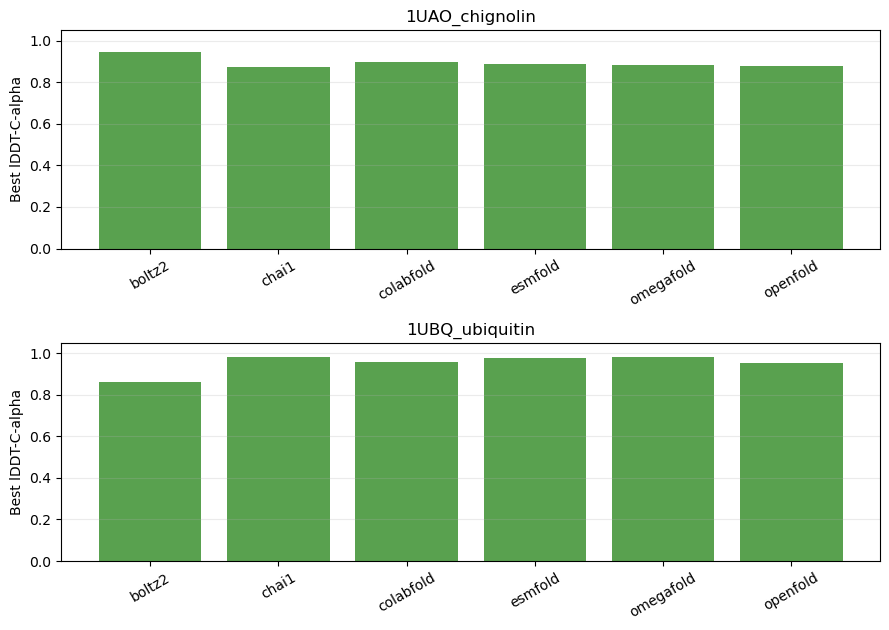

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

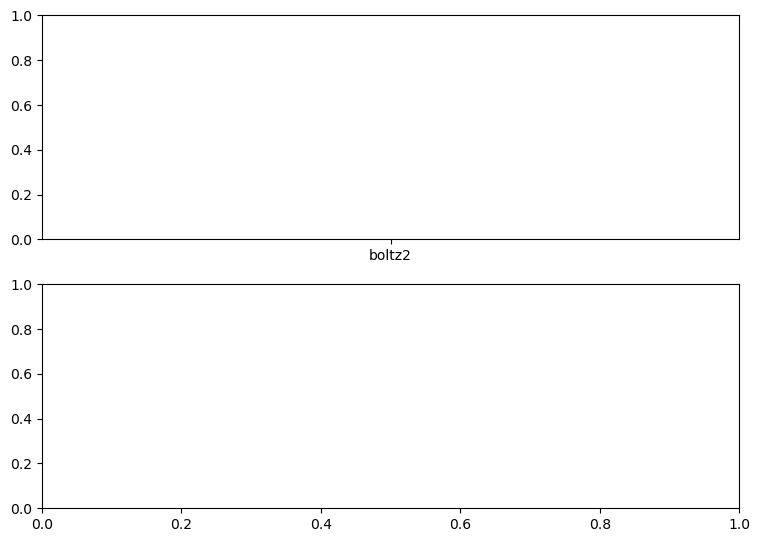

In [5]:
best_per_target = scores.sort_values([PRIMARY, SECONDARY], ascending=[False, False]).groupby(["target_id", "model"], as_index=False).first()
targets = sorted(best_per_target["target_id"].unique())
fig, axes = plt.subplots(len(targets), 1, figsize=(9, max(3.5, 3.2 * len(targets))), squeeze=False)
for ax, target in zip(axes.ravel(), targets):
    target_df = best_per_target[best_per_target["target_id"] == target].copy()
    target_df["model"] = pd.Categorical(target_df["model"], categories=MODEL_ORDER, ordered=True)
    target_df = target_df.sort_values("model")
    ax.bar(target_df["model"].astype(str), target_df[PRIMARY], color="#59A14F")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Best lDDT-C-alpha")
    ax.set_title(target)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "per_target_lddt_ca.png", dpi=160)
plt.show()

fig, axes = plt.subplots(len(targets), 1, figsize=(9, max(3.5, 3.2 * len(targets))), squeeze=False)
for ax, target in zip(axes.ravel(), targets):
    target_df = best_per_target[best_per_target["target_id"] == target].copy()
    target_df["model"] = pd.Categorical(target_df["model"], categories=MODEL_ORDER, ordered=True)
    target_df = target_df.sort_values("model")
    ax.bar(target_df["model"].astype(str), target_df[SECONDARY], color="#F28E2B")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Best TM-score ref")
    ax.set_title(target)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "per_target_tm_score_ref.png", dpi=160)
plt.show()

heatmap = best_per_target.pivot(index="target_id", columns="model", values=PRIMARY)
fig, ax = plt.subplots(figsize=(max(8, 0.8 * max(1, len(heatmap.columns))), max(4, 0.35 * max(1, len(heatmap)))))
image = ax.imshow(heatmap.fillna(0), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_title("Per-target Best lDDT-C-alpha Heatmap")
fig.colorbar(image, ax=ax, label="Best lDDT-C-alpha")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "per_target_lddt_ca_heatmap.png", dpi=160)
plt.show()

## Top-5 and Rank Behavior

,model,target_id,available_ranks,top_k_mode
0,boltz2,1UAO_chignolin,5,top-5
1,boltz2,1UBQ_ubiquitin,5,top-5
2,chai1,1UAO_chignolin,5,top-5
3,chai1,1UBQ_ubiquitin,5,top-5
4,colabfold,1UAO_chignolin,5,top-5
5,colabfold,1UBQ_ubiquitin,5,top-5
6,esmfold,1UAO_chignolin,1,top-1
7,esmfold,1UBQ_ubiquitin,1,top-1
8,omegafold,1UAO_chignolin,1,top-1
9,omegafold,1UBQ_ubiquitin,1,top-1


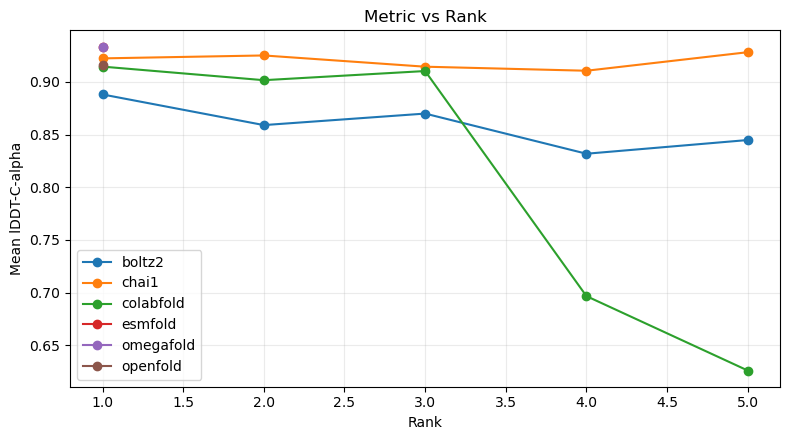

In [ ]:
rank_counts = scores.groupby(["model", "target_id"])["rank"].nunique().reset_index(name="available_ranks")
rank_counts["top_k_mode"] = rank_counts["model"].map(TOPK_MODE).fillna("unknown")
display(rank_counts.sort_values(["model", "target_id"]))

rank_df = scores.dropna(subset=["rank", PRIMARY]).copy()
if rank_df["rank"].nunique() > 1:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for model, group in rank_df.groupby("model"):
        by_rank = group.groupby("rank")[PRIMARY].mean().reset_index()
        ax.plot(by_rank["rank"], by_rank[PRIMARY], marker="o", label=model)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Mean lDDT-C-alpha")
    ax.set_title("Metric vs Rank")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "metric_vs_rank.png", dpi=160)
    plt.show()
else:
    print("Only rank-1 predictions are available in the loaded score files.")

## Best-of-5 Analysis

In [ ]:
best_of_5 = scores.groupby(["target_id", "model"]).agg(
    best_lddt_ca=(PRIMARY, "max"),
    best_tm_score=(SECONDARY, "max"),
    available_ranks=("rank", "nunique"),
).reset_index()
rank1 = scores[scores["rank"] == 1].groupby(["target_id", "model"]).agg(
    rank1_lddt_ca=(PRIMARY, "max"),
    rank1_tm_score=(SECONDARY, "max"),
).reset_index()
best_of_5 = best_of_5.merge(rank1, on=["target_id", "model"], how="left")
best_of_5["lddt_ca_gain_best_over_rank1"] = best_of_5["best_lddt_ca"] - best_of_5["rank1_lddt_ca"]
best_of_5["tm_score_gain_best_over_rank1"] = best_of_5["best_tm_score"] - best_of_5["rank1_tm_score"]
best_of_5.to_csv(SCORES_DIR / "best_of_5_summary.csv", index=False)
display(best_of_5.sort_values(["target_id", "model"]))

,target_id,model,best_lddt_ca,best_tm_score,available_ranks,rank1_lddt_ca,rank1_tm_score,lddt_ca_gain_best_over_rank1,tm_score_gain_best_over_rank1
0,1UAO_chignolin,boltz2,0.944444,NaN,5,0.916667,NaN,0.027778,NaN
1,1UAO_chignolin,chai1,0.872222,NaN,5,0.866667,NaN,0.005556,NaN
2,1UAO_chignolin,colabfold,0.900000,NaN,5,0.872222,NaN,0.027778,NaN
3,1UAO_chignolin,esmfold,0.888889,NaN,1,0.888889,NaN,0.000000,NaN
4,1UAO_chignolin,omegafold,0.883333,NaN,1,0.883333,NaN,0.000000,NaN
5,1UAO_chignolin,openfold,0.877778,NaN,1,0.877778,NaN,0.000000,NaN
6,1UBQ_ubiquitin,boltz2,0.859463,NaN,5,0.859463,NaN,0.000000,NaN
7,1UBQ_ubiquitin,chai1,0.984110,NaN,5,0.977931,NaN,0.006179,NaN
8,1UBQ_ubiquitin,colabfold,0.956744,NaN,5,0.956744,NaN,0.000000,NaN
9,1UBQ_ubiquitin,esmfold,0.977754,NaN,1,0.977754,NaN,0.000000,NaN


## Exported Files

- `figures/benchmark/model_mean_lddt_ca.png`
- `figures/benchmark/per_target_lddt_ca.png`
- `figures/benchmark/per_target_tm_score_ref.png`
- `figures/benchmark/model_lddt_ca_boxplot.png`
- `figures/benchmark/model_tm_score_ref_boxplot.png`
- `figures/benchmark/model_inference_time_sec_boxplot.png` when timing is available
- `figures/benchmark/speed_vs_lddt_ca.png` when timing is available
- `figures/benchmark/lddt_ca_vs_tm_score_ref.png`
- `figures/benchmark/per_target_lddt_ca_heatmap.png`
- `figures/benchmark/metric_vs_rank.png` when multiple ranks are available
- `data/scores/best_of_5_summary.csv`